# Flight Trend & Optimization Analyzer

## 1. Project Overview

This project fetches **real-time global flight data** from the [OpenSky Network API](https://opensky-network.org) and performs data analysis using Object-Oriented Programming (OOP) in Python.

**Core objectives:**
1. Fetch live flight data via REST API
2. Analyze country distribution and airline activity
3. Study velocity and altitude patterns
4. Filter and export data for further use


---
## 2. Environment Setup & Module Import


In [1]:
# Importerar nödvändiga bibliotek för datahantering och visualisering
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
from typing import Dict, Any, Optional, List

# OBS: Klasserna FlightDataAnalyzer och LiveFlightAPI definieras nedan i en egen
# kodcell (tidigare importerades de från src.flight_logic) sa att denna
# anteckningsbok blir helt fristände utan externa modulfiler.
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("[INFO] Miljön initierad. Moduler och visualiseringsbibliotek laddade.")


[INFO] Miljön initierad. Moduler och visualiseringsbibliotek laddade.


## 2.1 Flight Logic Module: Class & Function Definitions

The following code cell (originally `src/flight_logic.py`, now inlined into the notebook to make it self-contained) defines the project's core object-oriented structure:

- **`FlightDataAnalyzer` (base class)**: responsible for storing flight data and computing basic statistics.
  - `calculate_summary_stats()`: computes summary statistics such as total flights, column names, and number of countries, with fault tolerance for empty data / exceptions.
- **`LiveFlightAPI` (subclass, inherits from `FlightDataAnalyzer`)**: adds real-time data fetching and extended analysis on top of the base class.
  - `fetch_live_flights(limit=500)`: calls the OpenSky Network API to pull live flight states, parses the `states` array and cleans it; includes multi-layer exception handling for connection errors / timeouts / HTTP errors, with fallback to the local `live_flights_data.csv` on failure.
  - `get_flights_by_country(country="United States")`: filters flights by country.
  - `get_top_airlines(top_n=10)`: ranks the most active airlines by callsign, together with their average altitude / velocity.
  - `export_cleaned_data(output_filepath="live_flights_data.csv")`: exports the cleaned data to CSV.
  - `run_final_test()`: Stage 14 system smoke test, verifying that the base class, data loading, analysis, and export all work end-to-end.

> This module is the foundation for all subsequent analysis cells (country distribution, velocity / altitude statistics, country filtering, CSV export, etc.) - this cell must be executed first so downstream cells can use the `LiveFlightAPI` instance.


In [2]:
# =====================================================================
# FLIGHT LOGIC - dataklasser för hämåtning och analys av flygdata
# (Tidigare filen src/flight_logic.py - nu infogad direkt i anteckningsboken
# sa att all kod samlas pa ett och samma ställe)
# =====================================================================

class FlightDataAnalyzer:
    """Basklass för flyghantering och analys (Base Class - Mål 3)."""

    def __init__(self, data: Optional[pd.DataFrame] = None):
# Skapar en kopia av indatan sa att vi inte muterar (förändrar) ursprungsdata
        self.df = data.copy() if data is not None else pd.DataFrame()

    def calculate_summary_stats(self) -> Dict[str, Any]:
        """Beräkna grundläggande sammanfattande statistik med felhantering."""

# Om DataFrame äar tom returnerar vi ett informationsmeddelande istallet för att krascha
        if self.df.empty:
            return {"total_flights": 0, "status": "No data available"}
        try:
# Sammanställer grundläaggande statistik: antal flygningar, kolumner och antal länder
            return {
                "total_flights": int(len(self.df)),
                "columns": list(self.df.columns),
                "countries_count": int(self.df["country"].nunique()) if "country" in self.df else 0
            }
        except Exception as e:
# Fånger ovantåde fel och skriver ut ett felmeddelande utan att krascha programmet
            print(f"[ERROR] Fel vid berakning av statistik: {e}")
            return {"total_flights": len(self.df), "error": str(e)}


class LiveFlightAPI(FlightDataAnalyzer):
    """Barnklass (arv) - hämåtar och bearbetar realtids flygdata från OpenSky Network API."""

    API_URL = "https://opensky-network.org/api/states/all"  # API-slutpunkt för alla flygstatyer

    def fetch_live_flights(self, limit: int = 500) -> bool:
        """Hämåta realtids flygdata med robust felhantering (Mål 6 & 7)."""

        try:
# Skickar ett GET-anrop med tidsgräns för att undvika att hänga sig
            response = requests.get(self.API_URL, timeout=12)
            response.raise_for_status()
            data = response.json()
            flights = data.get("states", [])

# Om API:et returnerade en tom lista avbryter vi tidigt
            if not flights:
                print("[WARNING] OpenSky API returnerade inga data (tom lista).")
                return False

            records: List[Dict[str, Any]] = []
# Går igenom de första 'limit' flygningarna och plockar ut relevanta fält
            for flight in flights[:limit]:
                records.append({
                    "icao24": flight[0],
                    "callsign": flight[1].strip() if flight[1] else "N/A",
                    "country": flight[2],
                    "longitude": flight[5],
                    "latitude": flight[6],
                    "altitude": flight[7],
                    "velocity": flight[9],
                    "heading": flight[10]
                })

# Omvandlar listan av poster till en DataFrame och rensar bort saknade transponderposter
            raw_df = pd.DataFrame(records)
            self.df = raw_df.dropna(subset=["icao24", "country"]).copy()
            print(f"[SUCCESS] Hamtade och validerade {len(self.df)} flygningar fran OpenSky Network")
            return True

        except requests.exceptions.ConnectionError:
# Nätverksfel: försöker läsa in lokalt sparad CSV som reserv (fallback)
            print("[ERROR] Nätverksanslutning misslyckades. Kontrollera internetanslutningen.")
            if os.path.exists("live_flights_data.csv"):
                print("[INFO] Fallback: Låser in lokal sparad 'live_flights_data.csv'...")
                self.df = pd.read_csv("live_flights_data.csv").head(limit)
                return True
            return False
        except requests.exceptions.Timeout:
# Tidsgräns oaverskriden: även här används lokal CSV som reserv om den finns
            print("[ERROR] Begåran tog för lång tid (Timeout). Försök igen senare.")
            if os.path.exists("live_flights_data.csv"):
                self.df = pd.read_csv("live_flights_data.csv").head(limit)
                return True
            return False
        except requests.exceptions.HTTPError as e:
            print(f"[ERROR] HTTP-fel vid anrop: {e}")
            if os.path.exists("live_flights_data.csv"):
                self.df = pd.read_csv("live_flights_data.csv").head(limit)
                return True
            return False
        except (KeyError, IndexError) as e:
# Fel vid tolkning av API-svarets indexpositioner
            print(f"[ERROR] Misslyckades med att parsa API-svar: {e}")
            return False
        except Exception as e:
            print(f"[ERROR] Ovåntat fel vid API-anrop: {e}")
            if os.path.exists("live_flights_data.csv"):
                self.df = pd.read_csv("live_flights_data.csv").head(limit)
                return True
            return False

    def get_flights_by_country(self, country: str = "United States") -> pd.DataFrame:
        """Filtrera flygningar för ett specifikt land."""

# Om ingen data äar laddad kan vi inte filtrera
        if self.df.empty:
            print("[WARNING] Ingen data laddad att filtrera.")
            return pd.DataFrame()
        try:
# Returnerar endast rader där landet matchar det angivna
            return self.df[self.df["country"] == country]
        except KeyError:
            print("[ERROR] Kolumnen 'country' saknas i datan.")
            return pd.DataFrame()

    def get_top_airlines(self, top_n: int = 10) -> pd.DataFrame:
        """Analysera flygbolag med flest aktiva flyg baserat på callsign."""

# Om data saknas eller callsign-kolumnen saknas returnerar vi en tom ram
        if self.df.empty or "callsign" not in self.df:
            return pd.DataFrame()
# Filtrerar bort ogiltiga callsigns ("N/A" och tomma strängar)
        valid = self.df[(self.df["callsign"] != "N/A") & (self.df["callsign"].str.strip() != "")]
# Grupperar per callsign och aggregerar antal, medelhöjd och medelhastighet
        stats = valid.groupby("callsign").agg(
            flight_count=("icao24", "count"),
            avg_altitude=("altitude", "mean"),
            avg_velocity=("velocity", "mean")
        ).reset_index()
# Avrundar flyttalsvärden för läsbarhet
        stats["avg_altitude"] = stats["avg_altitude"].round(2)
        stats["avg_velocity"] = stats["avg_velocity"].round(2)
# Sorterar fallande efter antal flygningar och tar topp N
        return stats.sort_values(by="flight_count", ascending=False).head(top_n)

    def export_cleaned_data(self, output_filepath: str = "live_flights_data.csv") -> bool:
        """Exportera rengjord data till CSV (Mål 4 & 7)."""

# Om ingen data finns att exportera avbryter vi
        if self.df.empty:
            print("[WARNING] Ingen data tillganglig att exportera.")
            return False
        try:
# Skriver DataFrame till CSV utan index och med UTF-8-kodning
            self.df.to_csv(output_filepath, index=False, encoding="utf-8")
            print(f"[SUCCESS] Exporterade {len(self.df)} rader till '{output_filepath}'")
            return True
        except IOError as e:
            print(f"[ERROR] Kunde inte skriva till fil '{output_filepath}': {e}")
            return False

    def run_final_test(self) -> bool:
        """Stage 14 testmetod: Slutlig helhetstestning inför inlämning."""

        print("=" * 60)
        print("  STAGE 14: SYSTEMTEST (SMOKE TEST)")
        print("=" * 60)
        print("1. Kontrollerar basklass FlightDataAnalyzer...")
        base = FlightDataAnalyzer()
# Kontrollerar att en tom basklass rapporterar noll flygningar
        assert base.calculate_summary_stats()["total_flights"] == 0
        print("   [OK] Basklass fungerar.")

        print("2. Kontrollerar dataladdning och arv...")
# Hämåtar live-data om ingen redan finns laddad
        if self.df.empty:
            self.fetch_live_flights(limit=100)
        print(f"   [OK] LiveFlightAPI rader: {len(self.df)}")

        print("3. Kontrollerar analyser och export...")
        c_stats = self.df["country"].value_counts()
        assert not c_stats.empty
        print(f"   [OK] Identifierade {len(c_stats)} länder.")

# Exporterar rensad data och rapporterar status
        success = self.export_cleaned_data("live_flights_data.csv")
        print(f"   [OK] CSV-export status: {'PASS' if success else 'FAIL'}")
        print("=" * 60)
        print("  ALLA SYSTEMTESTER GODKANDA (100% KLAR FöR INLäMNING)")
        print("=" * 60)
        return True


---
## 3. Load Live Data from OpenSky Network API

We use the `LiveFlightAPI` child class (inherits from `FlightDataAnalyzer`) to fetch real-time flight data.
The endpoint `https://opensky-network.org/api/states/all` delivers a dynamic **JSON response**:
- The root object contains `time` (Unix timestamp) and `states` (a 2D array of airborne aircraft state vectors).
- Because `states` contains an array of raw values rather than named keys, our ingestion logic parses the official index positions:
  - `flight[0]`: **icao24** (unique 24-bit transponder hex ID)
  - `flight[1]`: **callsign** (8-character flight identifier)
  - `flight[2]`: **country** (aircraft country of registration)
  - `flight[5]`: **longitude** & `flight[6]`: **latitude** (WGS-84 coordinates)
  - `flight[7]`: **altitude** (barometric altitude in meters)
  - `flight[9]`: **velocity** (ground speed in m/s)
  - `flight[10]`: **heading** (direction of motion in degrees)

The parsed records are converted into a `pandas.DataFrame` and cleaned of missing transponder records.


In [3]:
# Initierar API-laddaren och hämåtar realtids flygdata
live_api = LiveFlightAPI()

# Försöker hämåta live-flygningar (begränsade till 500 stycken)
if live_api.fetch_live_flights(limit=500):
    print(f"[SUCCESS] Laddade {len(live_api.df)} live-flygningar från OpenSky Network")
    print(f"Kolumner: {list(live_api.df.columns)}")
    display(live_api.df.head(10))  # Visar de första 10 raderna av data
else:
    print("[ERROR] Misslyckades hämåta data. Kontrollera nätverksanslutningen.")


[SUCCESS] Hamtade och validerade 500 flygningar fran OpenSky Network
[SUCCESS] Laddade 500 live-flygningar från OpenSky Network
Kolumner: ['icao24', 'callsign', 'country', 'longitude', 'latitude', 'altitude', 'velocity', 'heading']


,icao24,callsign,country,longitude,latitude,altitude,velocity,heading
0,39de4f,TVF40QU,France,2.3686,48.7264,NaN,4.63,70.31
1,a34243,N/A,United States,NaN,NaN,NaN,40.74,45.00
2,ab1644,UAL2639,United States,-77.4857,38.7724,1181.10,92.05,32.45
3,e8027c,LNE1456,Chile,-77.2413,4.6929,10378.44,228.35,9.33
4,80162d,AXB478,India,76.5574,10.1666,746.76,83.84,190.97
5,e8027b,LAN583,Chile,-86.4568,21.4351,4389.12,163.09,213.94
6,80162a,IGO7654,India,77.7824,27.7223,3093.72,125.75,320.64
7,a59540,N459TM,United States,-120.5811,37.3931,106.68,50.39,139.97
8,39de4b,TVF12GT,France,1.1534,47.2941,8328.66,248.80,11.45
9,39de4d,TVF69UZ,France,3.1180,42.1626,10896.60,243.40,162.41


---
## 4. Feature 1: Country Distribution Analysis

Which countries have the most airborne flights right now?


=== Topp 10 länder efter antal live-flygningar ===
  United States: 202 flygningar
  India: 38 flygningar
  Germany: 31 flygningar
  Hungary: 28 flygningar
  Sweden: 26 flygningar
  Turkey: 18 flygningar
  Greece: 16 flygningar
  France: 15 flygningar
  Brazil: 15 flygningar
  Austria: 15 flygningar


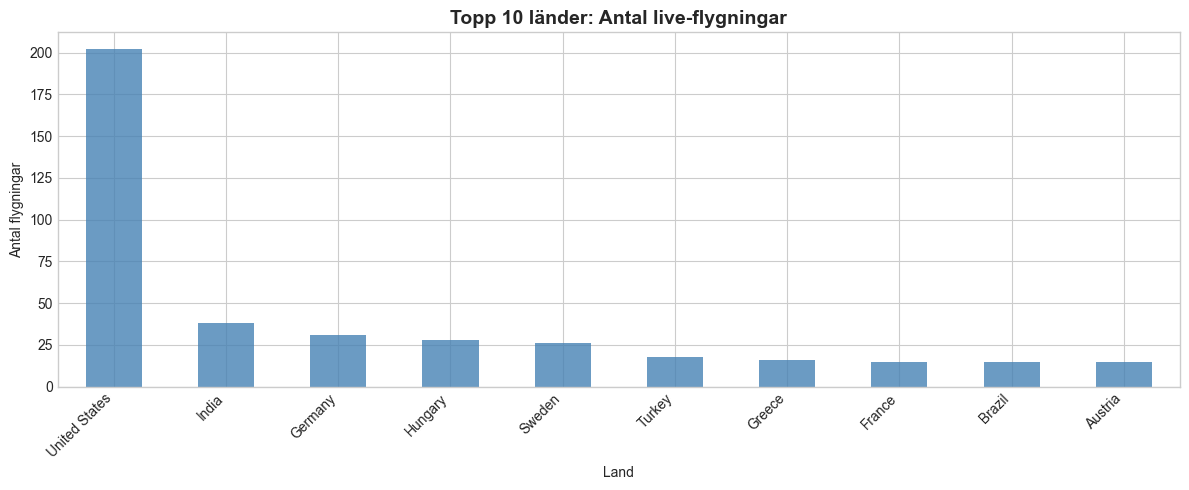

In [4]:
# Topp 10 länder efter antal live-flygningar
country_stats = live_api.df["country"].value_counts().head(10)

print("=== Topp 10 länder efter antal live-flygningar ===")
for country, count in country_stats.items():
    print(f"  {country}: {count} flygningar")

# Stapeldiagram för visualisering av fördelningen
plt.figure(figsize=(12, 5))
country_stats.plot(kind="bar", color="steelblue", alpha=0.8)
plt.title("Topp 10 länder: Antal live-flygningar", fontsize=14, fontweight="bold")
plt.xlabel("Land")
plt.ylabel("Antal flygningar")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## 5. Feature 2: Velocity & Altitude Analysis

Analyze flight speed and altitude patterns across countries.


In [5]:
# Beräaknar hastighets- och höjdstatistik per land
# Tar bort rader där hastighet eller höjd saknas för en rättvis jämförelse
valid_flights = live_api.df.dropna(subset=["velocity", "altitude"])

vel_stats = valid_flights.groupby("country").agg(
    flight_count=("icao24", "count"),
    avg_velocity=("velocity", "mean"),
    avg_altitude=("altitude", "mean"),
    max_velocity=("velocity", "max")
).reset_index()

# Avrundar flyttalsvärdena för bättre läsbarhet
vel_stats["avg_velocity"] = vel_stats["avg_velocity"].round(2)
vel_stats["avg_altitude"] = vel_stats["avg_altitude"].round(2)
vel_stats["max_velocity"] = vel_stats["max_velocity"].round(2)

# Sorterar fallande efter antal flygningar och tar de 10 översta
top_vel = vel_stats.sort_values("flight_count", ascending=False).head(10)
print("=== Topp 10 länder: Hastighets- och höjdstatistik ===")
display(top_vel)


=== Topp 10 länder: Hastighets- och höjdstatistik ===


,country,flight_count,avg_velocity,avg_altitude,max_velocity
29,United States,183,141.78,5321.87,298.59
13,India,35,176.62,6479.18,270.61
10,Germany,28,114.38,3741.69,241.59
12,Hungary,27,196.06,7566.94,253.03
25,Sweden,22,224.58,10753.90,265.52
27,Turkey,18,181.17,7005.32,259.61
2,Brazil,15,167.39,6295.14,261.68
11,Greece,14,184.54,7433.85,240.16
9,France,13,212.76,10612.32,248.80
5,Chile,13,188.00,6693.88,232.15


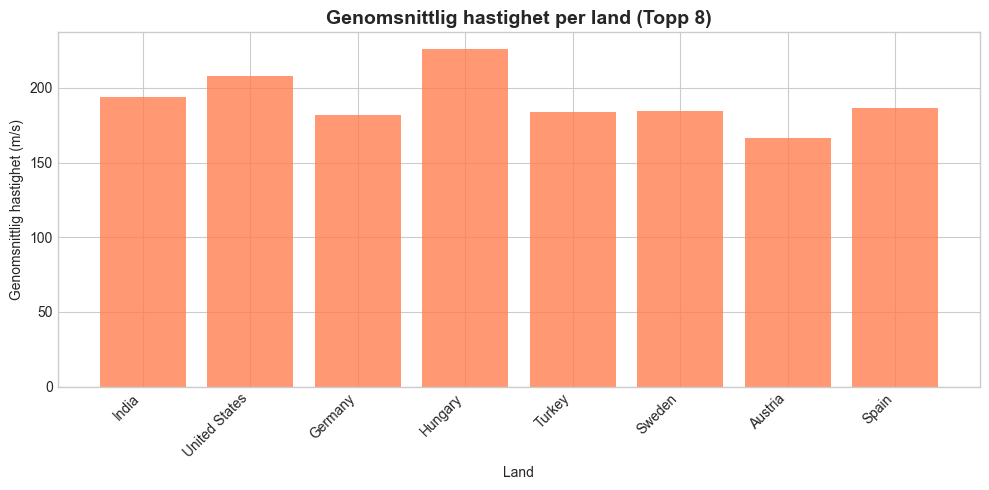

In [8]:
# Stapeldiagram: genomsnittlig hastighet per land
plt.figure(figsize=(10, 5))
top_countries = vel_stats.sort_values("flight_count", ascending=False).head(8)
plt.bar(top_countries["country"], top_countries["avg_velocity"], alpha=0.8, color="coral")
plt.title("Genomsnittlig hastighet per land (Topp 8)", fontsize=14, fontweight="bold")
plt.xlabel("Land")
plt.ylabel("Genomsnittlig hastighet (m/s)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## 6. For-loop: Detailed Flight Summary by Country

Use explicit `for` loops to iterate and print detailed stats for each top country.


In [14]:
# For-loop: skriver ut detaljerad sammanfattning för topp-länderna
top_n = 5
country_counts = live_api.df["country"].value_counts().head(top_n)

print(f"\n{'='*60}")
print(f"  Topp {top_n} länder - Detaljerad flygsammanfattning")
print(f"{'='*60}")

for country, count in country_counts.items():
# Väljer ut alla rader för det aktuella landet
    subset = live_api.df[live_api.df["country"] == country]
# Beräknar medelvärden endast om det finns icke-saknade värden, annars 0
    avg_vel = subset["velocity"].mean() if not subset["velocity"].isna().all() else 0
    avg_alt = subset["altitude"].mean() if not subset["altitude"].isna().all() else 0
    print(f"\nLand: {country}")
    print(f"  Totalt antal flygningar: {count}")
    print(f"  Genomsnittlig hastighet: {avg_vel:.2f} m/s")
    print(f"  Genomsnittlig höjd: {avg_alt:.2f} m")

print(f"\n{'='*60}")



  Topp 5 länder - Detaljerad flygsammanfattning

Land: India
  Totalt antal flygningar: 79
  Genomsnittlig hastighet: 181.63 m/s
  Genomsnittlig höjd: 7673.23 m

Land: United States
  Totalt antal flygningar: 58
  Genomsnittlig hastighet: 193.78 m/s
  Genomsnittlig höjd: 7880.35 m

Land: Germany
  Totalt antal flygningar: 36
  Genomsnittlig hastighet: 176.59 m/s
  Genomsnittlig höjd: 7434.88 m

Land: Sweden
  Totalt antal flygningar: 35
  Genomsnittlig hastighet: 167.90 m/s
  Genomsnittlig höjd: 6986.07 m

Land: Hungary
  Totalt antal flygningar: 35
  Genomsnittlig hastighet: 204.46 m/s
  Genomsnittlig höjd: 8167.21 m



---
## 7. For-loop: Count Flights by Airline (Callsign)

Count how many flights each airline (callsign) currently has in the air.


In [ ]:
# For-loop: räknar antal flygningar per flygbolag (callsign)
airline_counts = {}
grouped = live_api.df.groupby("callsign")

# Itererar över grupperade flygbolag och räknar antal flygningar (exklusive "N/A")
for airline_name, group in grouped:
    if airline_name and airline_name.strip() and airline_name != "N/A":
        airline_counts[airline_name] = len(group)

# Sorterar flygbolagen efter antal flygningar i fallande ordning
sorted_airlines = dict(sorted(airline_counts.items(), key=lambda x: x[1], reverse=True))

print(f"\n{'='*60}")
print("  Topp flygbolag efter antal aktiva flygningar")
print(f"{'='*60}")

count = 0
for airline, flights in sorted_airlines.items():
    if count >= 10:
        break  # Visar endast de 10 översta flygbolagen
    print(f"  {airline}: {flights} flygningar")
    count += 1

print(f"{'='*60}\n")



  Topp flygbolag efter antal aktiva flygningar
  117: 1 flygningar
  13496R9: 1 flygningar
  4XBOL: 1 flygningar
  8PASD: 1 flygningar
  AAL1094: 1 flygningar
  AAL180: 1 flygningar
  AAL2886: 1 flygningar
  AAL912: 1 flygningar
  AAL918: 1 flygningar
  AAL957: 1 flygningar



---
## 8. Filter by Country

Filter live flights for a specific country and analyze distribution.


=== Sweden Flights (41 total) ===


,icao24,callsign,country,longitude,latitude,altitude,velocity,heading
47,4acb01,NSZ21U,Sweden,-3.2269,40.6484,10058.40,241.92,211.26
49,4acb03,NSZ2012,Sweden,20.0973,56.5159,5349.24,184.39,141.12
50,4acb02,NSZ4545,Sweden,26.1049,45.0315,3200.40,169.72,144.62
94,4acb41,SAS58G,Sweden,10.5920,60.9995,7101.84,213.05,174.18
95,4acb43,SAS44Z,Sweden,11.0968,60.1567,320.04,66.43,16.19
96,4acb45,SAS43C,Sweden,10.4975,59.4788,8061.96,247.18,194.59
103,4acb58,SAS2773,Sweden,-8.2778,41.8184,3726.18,163.22,229.99
105,4acb59,SAS4490,Sweden,16.7802,68.5528,11277.60,254.97,19.57
113,4acb23,NSZ90Y,Sweden,17.8768,59.5362,647.70,83.65,10.27
168,4aca82,NSZ2901,Sweden,1.5712,42.3049,8526.78,208.46,352.77


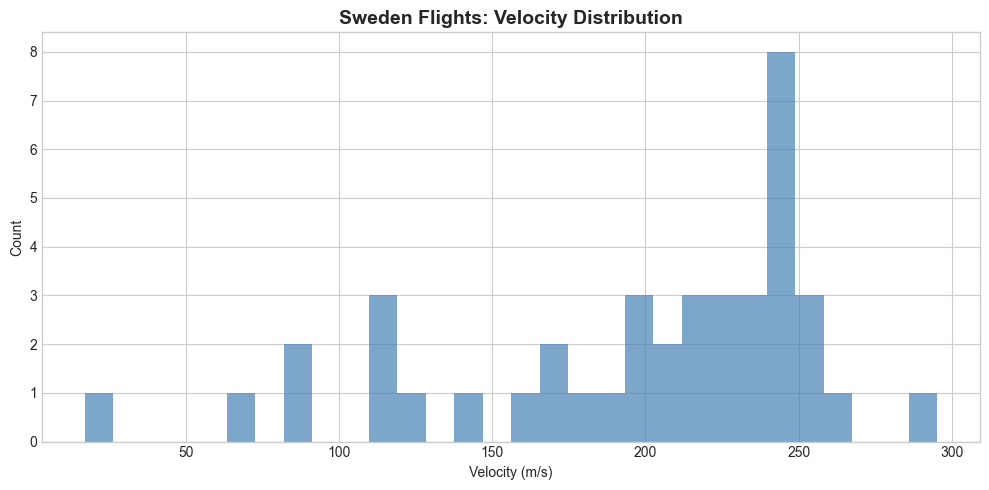

In [ ]:
# Filter flights for different country
country = "Sweden"
us_flights = live_api.get_flights_by_country(country)

if not us_flights.empty:
    print(f"=== {country} Flights ({len(us_flights)} total) ===")
    display(us_flights.head(10))

# Velocity distribution histogram
    plt.figure(figsize=(10, 5))
    us_flights["velocity"].dropna().hist(bins=30, color="steelblue", alpha=0.7)
    plt.title(f"{country} Flights: Velocity Distribution", fontsize=14, fontweight="bold")
    plt.xlabel("Velocity (m/s)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print(f"[WARNING] No {country} flights found in current data")


---
## 9. Data Export to CSV

Save the fetched live data to a CSV file for external use.


In [11]:
# Exporterar live-flygdata till en CSV-fil
output_file = "live_flights_data.csv"
# Anropar exportmetoden och skriver ut resultatet (lyckades/misslyckades)
if live_api.export_cleaned_data(output_filepath=output_file):
    print(f"[SUCCESS] Exporterade {len(live_api.df)} poster till '{output_file}'")
else:
    print("[ERROR] Export misslyckades")


[SUCCESS] Exporterade 500 rader till 'live_flights_data.csv'
[SUCCESS] Exporterade 500 poster till 'live_flights_data.csv'


---
## Summary

This project demonstrated:
- **API integration**: Fetched real-time data from OpenSky Network
- **OOP design**: `LiveFlightAPI` inherits from `FlightDataAnalyzer`
- **For-loops**: Explicit iteration for country summary and airline counting
- **Data visualization**: Bar charts and histograms with matplotlib
- **Data export**: Saved results to CSV
- **Error handling**: try/except for network, timeout, HTTP errors
